# 0.0 Project Overview

# 1.0 Loading appropraite packages

In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV # Version 1.5.2
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np # Version 1.22.4
import pandas as pd # Version 1.3.5
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt # Version 3.5.1
plt.style.use('default')
import seaborn as sns
import geopandas as gpd
from sklearn.metrics import classification_report, confusion_matrix
import shap

## 1.1 Loading in datasets

Population Estimate Data: https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates/datasets/lowersuperoutputareamidyearpopulationestimates

Access to Healthy Assets & Hazards (AHAH): https://data.geods.ac.uk/dataset/access-to-healthy-assets-hazards-ahah

LSOA to MSOA Converstion: https://geoportal.statistics.gov.uk/datasets/f9c8996d451f44b79ab97ddd369ad5db/about

Urban Rural Classifications
https://geoportal.statistics.gov.uk/datasets/374c3c23b3014496ba7121c3afb3a2ac_0/explore

In [2]:
ahah_df = pd.read_csv("/content/drive/MyDrive/Lincoln_data/ahah_v5.csv")

In [3]:
population_df = pd.read_csv("/content/drive/MyDrive/Lincoln_data/lsoa21_population_estimates.csv")
population_df.head(3)

,lsoa21cd,lsoa21name,total
0,E01011949,Hartlepool 009A,1898.0
1,E01011950,Hartlepool 008A,1247.0
2,E01011951,Hartlepool 007A,1393.0


In [4]:
lookup_df = pd.read_csv("/content/drive/MyDrive/Lincoln_data/PCD_OA21_LSOA21_MSOA21_LAD_FEB24_UK_LU.csv")

In [5]:
lookup_df = lookup_df[['lsoa21cd', 'msoa21cd', 'ladcd']]
lookup_df.head(2)

,lsoa21cd,msoa21cd,ladcd
0,S01006514,S02001237,S12000033
1,S01006514,S02001237,S12000033


In [6]:
granular_imd_df = pd.read_csv('/content/drive/MyDrive/Lincoln_data/IMD_Scores_LSOA_LAD.csv')
granular_imd_df.head(2)

,LSOAcode2021,LSOAname2021,LocalAuthorityDistrictcode2024,LocalAuthorityDistrictname2024,IMD_Rank,IMD_ Decile_LSOAs,Income_Rank,Income_Decile_LSOAs,Employment_Rank,Employment_Decile_ LSOAs,Education_Skills_Training_Rank,Education_Skills_Training_Decile,Health_Deprivation_and_Disability_Rank,Health_Deprivation_and_Disability_Decile_LSOAs,Crime_Rank,Crime_Decile_LSOAs,Barriers_to_Housing_Rank,Barriers_to_Housing_Decile_LSOAs,Living_Environment_Rank,Living_Environment_Decile_LSOAs
0,E01000001,City of London 001A,E09000001,City of London,26525,8,33730,10,33708,10,33755,10,33108,10,33698,10,29220,9,244,1
1,E01000002,City of London 001B,E09000001,City of London,31203,10,33669,10,33734,10,33672,10,32574,10,33712,10,32640,10,3702,2


In [7]:
lsoa_imd_df = pd.read_csv('/content/drive/MyDrive/Lincoln_data/lsoa_imd.csv')
lsoa_imd_df.head(2)

,lsoa21cd,lsoa21nm,lad21cd,lad21nm,imd_rank,imd_decile
0,E01000001,City of London 001A,E09000001,City of London,26525,8
1,E01000002,City of London 001B,E09000001,City of London,31203,10


# 2.0 Data Wrangling

## 2.1 Getting population stats for each LSOA

In [8]:
# strippiing white space
ahah_df['lsoa21cd'] = ahah_df['lsoa21cd'].str.strip()
population_df['lsoa21cd'] = population_df['lsoa21cd'].str.strip()
lookup_df['lsoa21cd'] = lookup_df['lsoa21cd'].str.strip()
lookup_df['msoa21cd'] = lookup_df['msoa21cd'].str.strip()


In [9]:
print(f"Lookup unique LSOAs: {lookup_df['lsoa21cd'].nunique()}")
print(f"Lookup unique MSOAs: {lookup_df['msoa21cd'].nunique()}")
print(f"AHAH unique LSOAs: {ahah_df['lsoa21cd'].nunique()}")

Lookup unique LSOAs: 43500
Lookup unique MSOAs: 8546
AHAH unique LSOAs: 43064


In [10]:
# matching LSOAs with population stats
merged_df = ahah_df.merge(population_df[['lsoa21cd', 'total']],
                        left_on='lsoa21cd',
                        right_on='lsoa21cd',
                        how='left')
merged_df.head(2)

,lsoa21cd,GP,bluespace,dentist,fast_food,gambling,greenspace_active,hospital,leisure,pharmacy,...,domain_g_rnk,domain_g_pct,domain_e_rnk,domain_e_pct,domain_r_rnk,domain_r_pct,ahah,ahah_rnk,ahah_pct,total
0,E01000001,1.886601,4.185294,1.003922,0.528431,1.692484,0.592484,1.458497,1.457516,1.077778,...,42870,100,43062,100,36982,86,60.326008,42984,100,2172.0
1,E01000002,1.850000,4.915490,0.634706,0.497059,1.397843,0.558824,1.969804,1.634706,1.428627,...,42966,100,43064,100,37500,88,61.707373,43003,100,2044.0


## 2.2 merging MSOA and LSOA codes

In [11]:
# Merge AHAH data with the full lookup dataframe
merged_df = merged_df.merge(lookup_df[['lsoa21cd', 'msoa21cd']],
                        left_on='lsoa21cd',
                        right_on='lsoa21cd',
                        how='left') # Use 'left' merge to keep all AHAH data

print("Merged DataFrame head:")

print("\nNumber of rows in merged_df:", len(merged_df))
print(f"Number of rows in merged_df before dropping duplicates: {len(merged_df)}")
merged_df_deduplicated = merged_df.drop_duplicates(subset=['lsoa21cd'])
print(f"Number of rows in merged_df after dropping duplicates: {len(merged_df_deduplicated)}")
merged_df = merged_df_deduplicated
merged_df

Merged DataFrame head:

Number of rows in merged_df: 2395548
Number of rows in merged_df before dropping duplicates: 2395548
Number of rows in merged_df after dropping duplicates: 43064


,lsoa21cd,GP,bluespace,dentist,fast_food,gambling,greenspace_active,hospital,leisure,pharmacy,...,domain_g_pct,domain_e_rnk,domain_e_pct,domain_r_rnk,domain_r_pct,ahah,ahah_rnk,ahah_pct,total,msoa21cd
0,E01000001,1.886601,4.185294,1.003922,0.528431,1.692484,0.592484,1.458497,1.457516,1.077778,...,100,43062,100,36982,86,60.326008,42984,100,2172.0,E02000001
146,E01000002,1.850000,4.915490,0.634706,0.497059,1.397843,0.558824,1.969804,1.634706,1.428627,...,100,43064,100,37500,88,61.707373,43003,100,2044.0,E02000001
467,E01000003,2.250000,5.195714,0.872381,0.850952,1.388095,0.411905,1.190476,1.411429,1.019524,...,99,43054,100,36677,86,56.232996,42886,100,2444.0,E02000001
516,E01000005,2.218924,2.173785,1.273958,0.426389,1.131597,0.642361,1.340799,2.314583,1.115625,...,99,43042,100,41964,98,67.096701,43048,100,2391.0,E02000001
815,E01000006,0.714286,2.752381,1.997619,1.053571,1.467857,1.345238,1.509524,2.866667,2.085714,...,99,42119,98,30484,71,49.822921,42490,99,1930.0,E02000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395307,W01002036,2.650556,1.350556,2.745000,1.850556,2.229444,0.466111,6.797778,2.297222,1.540556,...,61,17970,42,17832,42,18.069026,17650,41,1491.0,W02000241
2395370,W01002037,2.141667,0.716667,2.994697,2.077273,2.399242,0.632576,7.484091,3.053030,1.783333,...,82,17294,41,14694,35,22.269307,26154,61,1059.0,W02000241
2395415,W01002038,9.260417,1.373438,1.373438,6.860938,10.466146,0.936458,5.030729,6.814063,1.901042,...,71,7599,18,1889,5,18.859831,19367,45,1256.0,W02000250
2395473,W01002039,10.310606,0.940909,2.096212,7.660606,11.265909,0.345455,5.828030,7.611364,2.890152,...,19,6163,15,1406,4,15.928863,12775,30,1958.0,W02000250


## 2.3 Adding IMD Deciles

In [12]:
lsoa_imd_df = pd.read_csv('/content/drive/MyDrive/Lincoln_data/lsoa_imd.csv')
merged_df = merged_df.merge(lsoa_imd_df, left_on='lsoa21cd', right_on='lsoa21cd', how='left')
merged_df.head(2)

,lsoa21cd,GP,bluespace,dentist,fast_food,gambling,greenspace_active,hospital,leisure,pharmacy,...,ahah,ahah_rnk,ahah_pct,total,msoa21cd,lsoa21nm,lad21cd,lad21nm,imd_rank,imd_decile
0,E01000001,1.886601,4.185294,1.003922,0.528431,1.692484,0.592484,1.458497,1.457516,1.077778,...,60.326008,42984,100,2172.0,E02000001,City of London 001A,E09000001,City of London,26525.0,8.0
1,E01000002,1.850000,4.915490,0.634706,0.497059,1.397843,0.558824,1.969804,1.634706,1.428627,...,61.707373,43003,100,2044.0,E02000001,City of London 001B,E09000001,City of London,31203.0,10.0


## 2.4 Adding Granular Domains of IMD  

In [13]:
granular_imd_df = pd.read_csv('/content/drive/MyDrive/Lincoln_data/IMD_Scores_LSOA_LAD.csv')
merged_df = merged_df.merge(granular_imd_df, left_on='lsoa21cd', right_on='LSOAcode2021', how='left')
merged_df.head()

,lsoa21cd,GP,bluespace,dentist,fast_food,gambling,greenspace_active,hospital,leisure,pharmacy,...,Education_Skills_Training_Rank,Education_Skills_Training_Decile,Health_Deprivation_and_Disability_Rank,Health_Deprivation_and_Disability_Decile_LSOAs,Crime_Rank,Crime_Decile_LSOAs,Barriers_to_Housing_Rank,Barriers_to_Housing_Decile_LSOAs,Living_Environment_Rank,Living_Environment_Decile_LSOAs
0,E01000001,1.886601,4.185294,1.003922,0.528431,1.692484,0.592484,1.458497,1.457516,1.077778,...,33755.0,10.0,33108.0,10.0,33698.0,10.0,29220.0,9.0,244.0,1.0
1,E01000002,1.850000,4.915490,0.634706,0.497059,1.397843,0.558824,1.969804,1.634706,1.428627,...,33672.0,10.0,32574.0,10.0,33712.0,10.0,32640.0,10.0,3702.0,2.0
2,E01000003,2.250000,5.195714,0.872381,0.850952,1.388095,0.411905,1.190476,1.411429,1.019524,...,30273.0,9.0,20719.0,7.0,27325.0,9.0,30400.0,10.0,4540.0,2.0
3,E01000005,2.218924,2.173785,1.273958,0.426389,1.131597,0.642361,1.340799,2.314583,1.115625,...,15886.0,5.0,10458.0,4.0,25630.0,8.0,11294.0,4.0,5403.0,2.0
4,E01000006,0.714286,2.752381,1.997619,1.053571,1.467857,1.345238,1.509524,2.866667,2.085714,...,11134.0,4.0,21901.0,7.0,17875.0,6.0,2745.0,1.0,9479.0,3.0


# 3.0 Defining a baseline Mental Health Prevalence Estimates from the Adult Psychiatric Morbidity Survey: Survey of Mental Health and Wellbeing, England, 2023/4
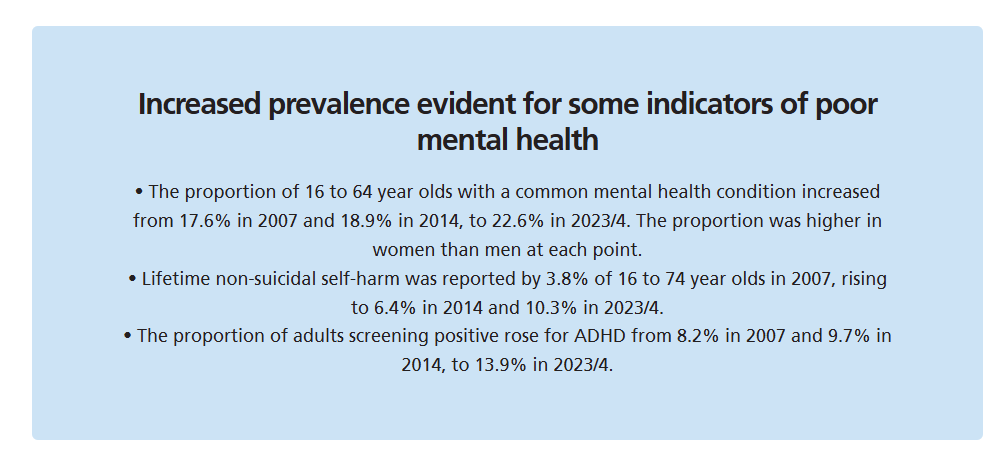

In [14]:
merged_df['baseline_cmhc_prevalence'] = 0.226

In [15]:
merged_df.columns

Index(['lsoa21cd', 'GP', 'bluespace', 'dentist', 'fast_food', 'gambling',
       'greenspace_active', 'hospital', 'leisure', 'pharmacy', 'pub_bar',
       'vape_tobacco', 'NO2', 'PM10', 'SO2', 'greenspace', 'GP_rnk',
       'dentist_rnk', 'pharmacy_rnk', 'hospital_rnk', 'leisure_rnk',
       'greenspace_active_rnk', 'greenspace_rnk', 'bluespace_rnk', 'NO2_rnk',
       'PM10_rnk', 'SO2_rnk', 'fast_food_rnk', 'gambling_rnk', 'pub_bar_rnk',
       'tobacco_rnk', 'GP_pct', 'dentist_pct', 'pharmacy_pct', 'hospital_pct',
       'leisure_pct', 'greenspace_pct', 'greenspace_active_pct',
       'bluespace_pct', 'NO2_pct', 'PM10_pct', 'SO2_pct', 'fast_food_pct',
       'gambling_pct', 'pub_bar_pct', 'tobacco_pct', 'domain_h', 'domain_g',
       'domain_e', 'domain_r', 'domain_h_rnk', 'domain_h_pct', 'domain_g_rnk',
       'domain_g_pct', 'domain_e_rnk', 'domain_e_pct', 'domain_r_rnk',
       'domain_r_pct', 'ahah', 'ahah_rnk', 'ahah_pct', 'total', 'msoa21cd',
       'lsoa21nm', 'lad21cd', 'lad21

# 4.0 LSOA to MSOA agregation starts here

In [16]:
cols_to_aggregate = [
    'NO2', 'PM10', 'SO2', 'greenspace',
    'Income_Decile_LSOAs',
    'Employment_Decile_ LSOAs',
    'Education_Skills_Training_Decile',
    'Crime_Decile_LSOAs',
    'GP',
    'bluespace',
    'greenspace_active',
    'imd_decile',
    'fast_food',
    'hospital', 'leisure', 'pharmacy'
]

msoa_df = (
    merged_df.groupby('msoa21cd')
    .apply(lambda x: pd.Series({
        col: np.average(x[col], weights=x['total'])
        for col in cols_to_aggregate
    }))
    .reset_index()
)

print(f"Unique MSOAs: {msoa_df['msoa21cd'].nunique()}")
print(msoa_df.shape)

Unique MSOAs: 7264
(7264, 17)


## 4.1 Adding Rural Classifications (for MSOAs)

In [17]:
urb_rur_classification_df = pd.read_csv('/content/drive/MyDrive/Lincoln_data/Rural_Urban_Classification_(2021)_of_LSOAs_in_EW.csv')
urb_rur_classification_df.head(2)

,LSOA21CD,LSOA21NM,LSOA21NMW,RUC21CD,RUC21NM,Urban_rural_flag,ObjectId
0,E01000001,City of London 001A,NaN,UN1,Urban: Nearer to a major town or city,Urban,1
1,E01000002,City of London 001B,NaN,UN1,Urban: Nearer to a major town or city,Urban,2


In [18]:
urb_rur_classification_df['RUC21NM'].value_counts()

,count
RUC21NM,
Urban: Nearer to a major town or city,27106
Urban: Further from a major town or city,2451
Larger rural: Nearer to a major town or city,2127
Smaller rural: Nearer to a major town or city,1735
Smaller rural: Further from a major town or city,1232
Larger rural: Further from a major town or city,1021


In [19]:
classification_mapping = {
    'Urban: Nearer to a major town or city': 1,
    'Urban: Further from a major town or city': 2,
    'Larger rural: Nearer to a major town or city': 3,
    'Smaller rural: Nearer to a major town or city': 4,
    'Smaller rural: Further from a major town or city': 5,
    'Larger rural: Further from a major town or city': 6
}
urb_rur_classification_df['RUC_numeric'] = urb_rur_classification_df['RUC21NM'].map(classification_mapping)
merged_df = merged_df.merge(urb_rur_classification_df[['LSOA21CD', 'LSOA21NM', 'RUC21NM', 'Urban_rural_flag', 'RUC_numeric']],
                        left_on='lsoa21cd',
                        right_on='LSOA21CD',
                        how='left')


In [20]:
merged_df = merged_df[~merged_df['lsoa21cd'].str.startswith('W')]
merged_df = merged_df[~merged_df['lsoa21cd'].str.startswith('S')]
print(f"Shape of msoa_df after dropping Welsh LSOAs: {merged_df.shape}")

Shape of msoa_df after dropping Welsh LSOAs: (33755, 94)


In [21]:
merged_df

,lsoa21cd,GP,bluespace,dentist,fast_food,gambling,greenspace_active,hospital,leisure,pharmacy,...,Barriers_to_Housing_Rank,Barriers_to_Housing_Decile_LSOAs,Living_Environment_Rank,Living_Environment_Decile_LSOAs,baseline_cmhc_prevalence,LSOA21CD,LSOA21NM,RUC21NM,Urban_rural_flag,RUC_numeric
0,E01000001,1.886601,4.185294,1.003922,0.528431,1.692484,0.592484,1.458497,1.457516,1.077778,...,29220.0,9.0,244.0,1.0,0.226,E01000001,City of London 001A,Urban: Nearer to a major town or city,Urban,1.0
1,E01000002,1.850000,4.915490,0.634706,0.497059,1.397843,0.558824,1.969804,1.634706,1.428627,...,32640.0,10.0,3702.0,2.0,0.226,E01000002,City of London 001B,Urban: Nearer to a major town or city,Urban,1.0
2,E01000003,2.250000,5.195714,0.872381,0.850952,1.388095,0.411905,1.190476,1.411429,1.019524,...,30400.0,10.0,4540.0,2.0,0.226,E01000003,City of London 001C,Urban: Nearer to a major town or city,Urban,1.0
3,E01000005,2.218924,2.173785,1.273958,0.426389,1.131597,0.642361,1.340799,2.314583,1.115625,...,11294.0,4.0,5403.0,2.0,0.226,E01000005,City of London 001E,Urban: Nearer to a major town or city,Urban,1.0
4,E01000006,0.714286,2.752381,1.997619,1.053571,1.467857,1.345238,1.509524,2.866667,2.085714,...,2745.0,1.0,9479.0,3.0,0.226,E01000006,Barking and Dagenham 016A,Urban: Nearer to a major town or city,Urban,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,2.991852,0.682963,0.934074,0.899630,1.063333,0.451481,1.022593,1.472222,0.872222,...,23743.0,8.0,25435.0,8.0,0.226,E01035758,Vale of White Horse 014H,Urban: Further from a major town or city,Urban,2.0
33751,E01035759,5.512097,2.299194,5.062903,2.862634,6.419355,0.772043,3.676075,5.711022,2.146774,...,12406.0,4.0,28626.0,9.0,0.226,E01035759,Vale of White Horse 015G,Urban: Nearer to a major town or city,Urban,1.0
33752,E01035760,3.010145,2.136232,2.048551,2.264493,3.864130,1.050725,2.267029,3.327536,1.595652,...,30084.0,9.0,31180.0,10.0,0.226,E01035760,Vale of White Horse 015H,Urban: Nearer to a major town or city,Urban,1.0
33753,E01035761,4.404710,3.438043,2.947101,3.695652,5.614855,0.734058,3.807971,5.026812,3.245652,...,18053.0,6.0,29506.0,9.0,0.226,E01035761,Vale of White Horse 015I,Urban: Nearer to a major town or city,Urban,1.0


In [22]:
merged_df.to_csv('linsoln_data_for_qgis.csv')

# private greensapce access

In [23]:
private_greenspace_access_df = pd.read_csv('/content/drive/MyDrive/Lincoln_data/lsoa_green_space_access.csv')
private_greenspace_access_df.columns

Index(['MSOA code', 'MSOA name', 'LSOA code', 'LSOA name',
       'Index of Multiple Deprivation rank (country specific)',
       'Index of Multiple Deprivation decile (country specific)',
       'Average distance to nearest Park, Public Garden, or Playing Field (m)',
       'Average size of nearest Park, Public Garden, or Playing Field (m2)',
       'Average number of  Parks, Public Gardens, or Playing Fields within 1,000 m radius',
       'Average combined size of  Parks, Public Gardens, or Playing Fields within 1,000 m radius (m2)'],
      dtype='object')

In [24]:
merged_df = merged_df.merge(private_greenspace_access_df[['LSOA code', 'Average size of nearest Park, Public Garden, or Playing Field (m2)']],
                        left_on='lsoa21cd',
                        right_on='LSOA code',
                        how='left')

In [25]:
merged_df['Average size of nearest Park, Public Garden, or Playing Field (m2)'].isna().sum()

np.int64(2133)

# 5.0 Generating Synthetic Mental Health Estimates

In [26]:
from scipy.special import logit, expit
import numpy as np

np.random.seed(42)

# Start every MSOA at the APMS baseline on the log-odds scale
baseline = logit(0.226)  # converts 22.6% to log-odds ≈ -1.23
df = merged_df
# Normalise features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['NO2_n']    = scaler.fit_transform(df[['NO2']])
df['green_n']  = scaler.fit_transform(df[['greenspace_active']])
df['income_n'] = scaler.fit_transform(df[['Income_Decile_LSOAs']])
log_odds = (
    baseline
    + 0.13 * df['NO2_n']
    - 0.06 * df['green_n']        # from literature
    + 0.49 * (1 - df['income_n'])
    + np.random.normal(0, 0.1, len(df))
)
'''to update log_odds = (
    baseline
    + 0.13 * df['NO2_n']
    - 0.06 * df['green_n']        # from literature
    + 0.49 * (1 - df['income_n'])
    + 0.30 * (1 - df['education_n'])
    + 0.30 * (1 - df['crime_n'])
    + np.random.normal(0, 0.1, len(df))
)'''
df['cmd_prevalence'] = expit(log_odds)

# Threshold at median not APMS baseline
threshold = df['cmd_prevalence'].median()
df['high_cmd'] = (df['cmd_prevalence'] > threshold).astype(int)

print(f"Threshold: {threshold:.4f}")
print(df['high_cmd'].value_counts())
print(df.groupby('Urban_rural_flag')['high_cmd'].mean())

Threshold: 0.2762
high_cmd
0    16878
1    16877
Name: count, dtype: int64
Urban_rural_flag
Rural    0.238747
Urban    0.551434
Name: high_cmd, dtype: float64


In [27]:
df['cmd_prevalence'].describe()

,cmd_prevalence
count,33755.000000
mean,0.278198
std,0.038345
min,0.168569
25%,0.248225
50%,0.276220
75%,0.306555
max,0.412939


In [28]:
print(df.groupby('Urban_rural_flag')['cmd_prevalence'].describe())

                    count      mean       std       min       25%       50%  \
Urban_rural_flag                                                              
Rural              5554.0  0.256823  0.029001  0.180934  0.235851  0.254535   
Urban             28201.0  0.282407  0.038556  0.168569  0.252384  0.282354   

                      75%       max  
Urban_rural_flag                     
Rural             0.27502  0.378631  
Urban             0.31117  0.412939  


In [29]:
# Sanity check — low income decile should associate with high cmd_prevalence
print(df.groupby('Income_Decile_LSOAs')['cmd_prevalence'].mean().round(3))

Income_Decile_LSOAs
1.0     0.331
2.0     0.319
3.0     0.307
4.0     0.294
5.0     0.282
6.0     0.271
7.0     0.260
8.0     0.249
9.0     0.239
10.0    0.230
Name: cmd_prevalence, dtype: float64


In [30]:
print("\nMean cmd_prevalence by urban/rural:")
print(df.groupby('Urban_rural_flag')['cmd_prevalence'].mean().round(4))

print("\nDifference between urban and rural means:")
urban_mean = df[df['Urban_rural_flag']=='Urban']['cmd_prevalence'].mean()
rural_mean = df[df['Urban_rural_flag']=='Rural']['cmd_prevalence'].mean()
print(f"Urban: {urban_mean:.4f}")
print(f"Rural: {rural_mean:.4f}")
print(f"Gap: {urban_mean - rural_mean:.4f}")


Mean cmd_prevalence by urban/rural:
Urban_rural_flag
Rural    0.2568
Urban    0.2824
Name: cmd_prevalence, dtype: float64

Difference between urban and rural means:
Urban: 0.2824
Rural: 0.2568
Gap: 0.0256


# 6.0 Random Forest Aanlysis

In [30]:
merged_df.columns

Index(['lsoa21cd', 'GP', 'bluespace', 'dentist', 'fast_food', 'gambling',
       'greenspace_active', 'hospital', 'leisure', 'pharmacy',
       ...
       'RUC21NM', 'Urban_rural_flag', 'RUC_numeric', 'LSOA code',
       'Average size of nearest Park, Public Garden, or Playing Field (m2)',
       'NO2_n', 'green_n', 'income_n', 'cmd_prevalence', 'high_cmd'],
      dtype='object', length=101)

## 6.1 Importing Lobraries and Defining a Data Split Function Across Different Seeds

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
import numpy as np

random_states = [40, 41, 42, 43, 44]

features = [
    # Environmental pollutant (brief requirement)
    'NO2',
    # Green/blue space
    'greenspace', 'bluespace', #'Average size of nearest Park, Public Garden, or Playing Field (m2)',
    # Overall deprivation
    'imd_decile',
    # Healthcare access
    'GP', 'hospital', 'pharmacy',
    # Healthy environment
    'leisure'
]

def create_test_train_sets(random_states, dataset_to_split,
                           test_size=0.30,
                           target_feature='high_cmd'):
    scaler = MinMaxScaler()
    sets = []

    # Use full dataset - no subsampling
    X = dataset_to_split[features]
    y = dataset_to_split[target_feature]

    for i in random_states:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=i,
            stratify=y)  # stratify on target only

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
        X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

        sets.append({
            'X_train': X_train_scaled_df,
            'X_test': X_test_scaled_df,
            'y_train': y_train,
            'y_test': y_test,
        })

    return sets

train_test_sets = create_test_train_sets(
    random_states=random_states,
    dataset_to_split=df,
    target_feature='high_cmd'
)

In [32]:
for i, s in enumerate(train_test_sets):
    test_indices = s['X_test'].index
    urban_count = (df.loc[test_indices, 'Urban_rural_flag'] == 'Urban').sum()
    rural_count = (df.loc[test_indices, 'Urban_rural_flag'] == 'Rural').sum()
    print(f"Seed {random_states[i]}: Urban={urban_count}, Rural={rural_count}")

Seed 40: Urban=8482, Rural=1645
Seed 41: Urban=8457, Rural=1670
Seed 42: Urban=8441, Rural=1686
Seed 43: Urban=8431, Rural=1696
Seed 44: Urban=8480, Rural=1647


## 6.2 Defining functions to extract results and parameters for each dataset and optimal model

In [33]:
def extract_pattern(input_list, start=0, step=4, group_size=4):
    """
    Extracts a pattern from the input list based on the specified start, step, and group size.

    Parameters:
    input_list (list): The list from which to extract the pattern.
    start (int): The starting index for extraction.
    step (int): The step size for extraction.
    group_size (int): The size of each group to extract.

    Returns:
    list: A list containing the extracted pattern.
    """
    result = []
    for i in range(start, len(input_list), step):
        if i + group_size <= len(input_list):
            result.extend(input_list[i:i+group_size])
    return result

def create_rf_results_df(model_results_list):
    """
    Creates a DataFrame from the model results list.

    Parameters:
    model_results_list (list): The list containing model results.

    Returns:
    DataFrame: A pandas DataFrame containing the model results.
    """
    columns = ['Random State', 'Model Accuracy', 'Cross Validation Accuracy', 'Optimal Parameters', 'True Positives', 'False Negatives', 'False Positives', 'True Negatives']
    extracted_elements = extract_pattern(model_results_list)
    rf_result_df = pd.DataFrame([extracted_elements[i:i+8] for i in range(0, len(extracted_elements), 8)], columns=columns)
    return rf_result_df

def dispay_df(df, name, accuracy_column='Model Accuracy', cross_val_column='Cross Validation Accuracy'):
    """
    Displays the DataFrame and prints the average model accuracy and cross-validation accuracy.

    Parameters:
    df (DataFrame): The DataFrame to display.
    name (str): The name of the DataFrame.
    accuracy_column (str): The column name for model accuracy.
    cross_val_column (str): The column name for cross-validation accuracy.
    """
    print(f"\n--- {name} ---")
    print(f"Average Model Accuracy: {df[accuracy_column].mean():.4f}")
    print("\n")
    print(f"Average Cross Validation Accuracy: {df[cross_val_column].mean():.4f}")
    display(df)

## 6.3 The RF Classifier Function

In [34]:
def rf_classifier_loop(custom_test_train_sets, random_state=random_states):
    from sklearn.ensemble import RandomForestClassifier
    param_grid = {
        'n_estimators': [200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
    }

    for random_state in random_states:
        for i, dataset in enumerate(custom_test_train_sets):

            rf_clf = RandomForestClassifier(random_state=random_state, bootstrap=False, class_weight='balanced',)

    # Instantiate the grid search model
            grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid,
                                    cv=5, n_jobs=-1, verbose=0, scoring='accuracy')

            # Fit the grid search to the data
            grid_search.fit(dataset['X_train'], dataset['y_train'])

            # Print the best parameters
            #print("Best parameters found: ", grid_search.best_params_)

            # Get the best model
            best_rf = grid_search.best_estimator_
            cross_validation_accuracy = grid_search.best_score_
            # Make predictions using the best model
            y_pred = best_rf.predict(dataset['X_test'])


            #print(f"-------Dataset{i}-------")
            #print(f"Random State: {random_state}")
            a_score = accuracy_score(dataset['y_test'], y_pred)

            #print("accuracy score ---- ", accuracy_score(dataset['y_test'], y_pred))

            conf_matrix = confusion_matrix(dataset['y_test'], y_pred)
            #print("Confusion Matrix:\n", conf_matrix)

            # Extract TP, FN, FP and TN from confusion matrix
            TP = conf_matrix[1, 1]
            FN = conf_matrix[1, 0]
            FP = conf_matrix[0, 1]
            TN = conf_matrix[0, 0]
            print("\n")

            yield a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN,  FP, TN
# calling the function
rf_scores_list_all_covariates = []
for i, (a_score, random_state, dataset, best_rf, cross_validation_accuracy, TP, FN, FP, TN) in enumerate(rf_classifier_loop(custom_test_train_sets=train_test_sets)):
    rf_scores_list_all_covariates.extend([
        random_state,
        a_score,
        cross_validation_accuracy,
        best_rf,
        TP,
        FN,
        FP,
        TN
    ])

## 6.4 Reviewing the model results

In [35]:
rf_results_all_covariates_df = create_rf_results_df(rf_scores_list_all_covariates)
dispay_df(rf_results_all_covariates_df, "All Covariates")


--- All Covariates ---
Average Model Accuracy: 0.8445


Average Cross Validation Accuracy: 0.8438


,Random State,Model Accuracy,Cross Validation Accuracy,Optimal Parameters,True Positives,False Negatives,False Positives,True Negatives
0,40,0.849116,0.842178,"(DecisionTreeClassifier(max_depth=10, max_feat...",4233,830,698,4366
1,40,0.842698,0.844591,"(DecisionTreeClassifier(max_depth=10, max_feat...",4192,871,722,4342
2,40,0.840822,0.845353,"(DecisionTreeClassifier(max_depth=10, max_feat...",4201,862,750,4314
3,40,0.848820,0.841714,"(DecisionTreeClassifier(max_depth=10, max_feat...",4228,835,696,4368
4,40,0.841612,0.845268,"(DecisionTreeClassifier(max_depth=10, max_feat...",4175,888,716,4348
5,41,0.848030,0.842094,"(DecisionTreeClassifier(max_depth=10, max_feat...",4227,836,703,4361
6,41,0.842402,0.844676,"(DecisionTreeClassifier(max_depth=10, max_feat...",4186,877,719,4345
7,41,0.840822,0.845141,"(DecisionTreeClassifier(max_depth=10, max_feat...",4198,865,747,4317
8,41,0.847931,0.841544,"(DecisionTreeClassifier(max_depth=10, max_feat...",4228,835,705,4359
9,41,0.841118,0.845268,"(DecisionTreeClassifier(max_depth=10, max_feat...",4165,898,711,4353


In [36]:
rf_results_all_covariates_df.to_csv('/content/drive/MyDrive/Lincoln_data/model_results_combined_lsoa.csv')

## 6.5 Extracting the results to a dataframe

In [37]:
def extract_and_mode_rf_params(df_column):
    """
    Extract all parameter values and find modes from RandomForestClassifier strings in DataFrame column

    Parameters:
    df_column (pandas.Series): DataFrame column containing RandomForestClassifier strings

    Returns:
    tuple: (parameter counts dict, parameter modes dict)
    """
    from collections import Counter

    # Initialize counters for each parameter
    param_counts = {
        'bootstrap': Counter(),
        'criterion': Counter(),
        'max_depth': Counter(),
        'min_samples_split': Counter(),
        'n_estimators': Counter(),
        'random_state': Counter(),
        'class_weight': Counter()
    }

    for rf_string in df_column:
        # Convert to string and clean up
        rf_string = str(rf_string)
        params_str = rf_string.strip('"').replace('\n', ' ')
        params_str = params_str.replace('RandomForestClassifier(', '').rstrip(')')
        params = params_str.split(', ')

        # Track parameters found in this configuration
        found_params = set()

        # Extract and count parameter values
        for param in params:
            name, value = param.split('=')
            # Strip whitespace from parameter name
            name = name.strip()
            found_params.add(name)

            # Convert value to appropriate type
            if value.lower() == 'false':
                value = False
            elif value.lower() == 'true':
                value = True
            elif value.isdigit():
                value = int(value)
            elif value.startswith("'") and value.endswith("'"):
                value = value.strip("'")

            # Strip any whitespace from the value if it's a string
            if isinstance(value, str):
                value = value.strip()

            param_counts[name][value] += 1

        # Add default values for any missing parameters
        for param in param_counts:
            if param not in found_params:
                if param == 'criterion':
                    param_counts[param]['gini (default)'] += 1

    # Find mode (most common value) for each parameter
    param_modes = {}
    for param, counts in param_counts.items():
        if counts:  # if there are any values
            mode_value = counts.most_common(1)[0][0]  # get the most common value
            mode_count = counts.most_common(1)[0][1]  # get its count
            total = sum(counts.values())
            mode_percentage = (mode_count / total) * 100
            param_modes[param] = (mode_value, mode_percentage)

    return param_counts, param_modes

def print_results(param_modes):
    print("\nMode values for the Base Model:")
    for param, (mode_value, percentage) in param_modes.items():
        print(f"{param}: {mode_value} ({percentage:.1f}%)")

param_counts, param_modes = extract_and_mode_rf_params(rf_results_all_covariates_df['Optimal Parameters'])
print_results(param_modes)


Mode values for the Base Model:
bootstrap: False (100.0%)
criterion: gini (default) (100.0%)
max_depth: 10 (100.0%)
min_samples_split: 5 (100.0%)
n_estimators: 200 (100.0%)
random_state: 40 (20.0%)
class_weight: balanced (100.0%)


In [38]:
# Get modal params from results
param_counts, param_modes = extract_and_mode_rf_params(
    rf_results_all_covariates_df['Optimal Parameters']  # changed from rf_results_all_covariates_df
)
print_results(param_modes)

# Get best model
best_row = rf_results_all_covariates_df.loc[rf_results_all_covariates_df['Model Accuracy'].idxmax()]
best_seed = int(best_row['Random State'])
print(f"\nBest seed: {best_seed}, accuracy: {best_row['Model Accuracy']:.4f}")

# Get corresponding test set
best_idx = random_states.index(best_seed)
best_test = train_test_sets[best_idx]

# Retrain with modal params
best_rf = RandomForestClassifier(
    n_estimators=param_modes['n_estimators'][0],
    max_depth=param_modes['max_depth'][0],
    criterion=param_modes['criterion'][0] if 'gini (default)' not in param_modes['criterion'][0] else 'gini',
    bootstrap=param_modes['bootstrap'][0],
    min_samples_split=param_modes['min_samples_split'][0],
    class_weight='balanced',
    random_state=42
)
best_rf.fit(best_test['X_train'], best_test['y_train'])
print(f"\nRetrained with modal params: {best_rf.get_params()}")


Mode values for the Base Model:
bootstrap: False (100.0%)
criterion: gini (default) (100.0%)
max_depth: 10 (100.0%)
min_samples_split: 5 (100.0%)
n_estimators: 200 (100.0%)
random_state: 40 (20.0%)
class_weight: balanced (100.0%)

Best seed: 42, accuracy: 0.8498

Retrained with modal params: {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


# 6.6 Reviewing Model Confusion Matirix

In [39]:
# Get best model from results DataFrame
best_row = rf_results_all_covariates_df.loc[rf_results_all_covariates_df['Model Accuracy'].idxmax()]
best_seed = int(best_row['Random State'])
print(f"Best seed: {best_seed}, accuracy: {best_row['Model Accuracy']:.4f}")

# Get corresponding test set
best_idx = random_states.index(best_seed)
best_test = train_test_sets[best_idx]

Best seed: 42, accuracy: 0.8498



--- Classification Report ---
              precision    recall  f1-score   support

     Low CMD       0.83      0.85      0.84      5064
    High CMD       0.85      0.83      0.84      5063

    accuracy                           0.84     10127
   macro avg       0.84      0.84      0.84     10127
weighted avg       0.84      0.84      0.84     10127



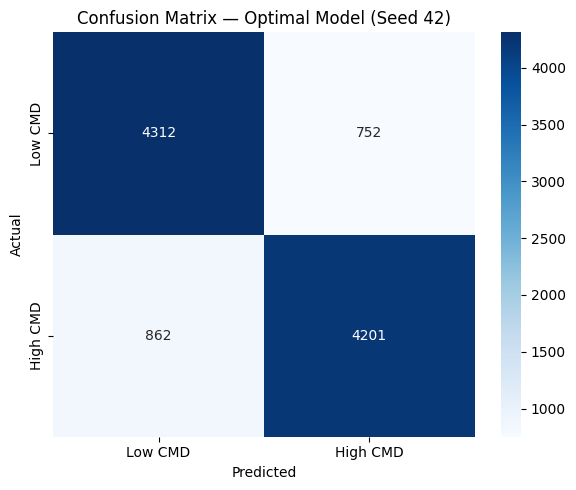


--- Urban Performance ---
              precision    recall  f1-score   support

     Low CMD       0.83      0.83      0.83      3779
    High CMD       0.86      0.86      0.86      4662

    accuracy                           0.84      8441
   macro avg       0.84      0.84      0.84      8441
weighted avg       0.84      0.84      0.84      8441


--- Rural Performance ---
              precision    recall  f1-score   support

     Low CMD       0.86      0.92      0.89      1285
    High CMD       0.67      0.50      0.57       401

    accuracy                           0.82      1686
   macro avg       0.76      0.71      0.73      1686
weighted avg       0.81      0.82      0.81      1686



In [40]:

# Predictions
y_pred = best_rf.predict(best_test['X_test'])
y_test = best_test['y_test']

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred,
                            target_names=['Low CMD', 'High CMD']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low CMD', 'High CMD'],
            yticklabels=['Low CMD', 'High CMD'])
ax.set_title(f'Confusion Matrix — Optimal Model (Seed {best_seed})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_optimal.png', dpi=150, bbox_inches='tight')
plt.show()

# Stratified by Urban/Rural
test_indices = best_test['X_test'].index
urban_mask = df.loc[test_indices, 'Urban_rural_flag'] == 'Urban'
rural_mask = df.loc[test_indices, 'Urban_rural_flag'] == 'Rural'

print("\n--- Urban Performance ---")
print(classification_report(y_test[urban_mask], y_pred[urban_mask],
                            target_names=['Low CMD', 'High CMD']))

print("\n--- Rural Performance ---")
print(classification_report(y_test[rural_mask], y_pred[rural_mask],
                            target_names=['Low CMD', 'High CMD']))

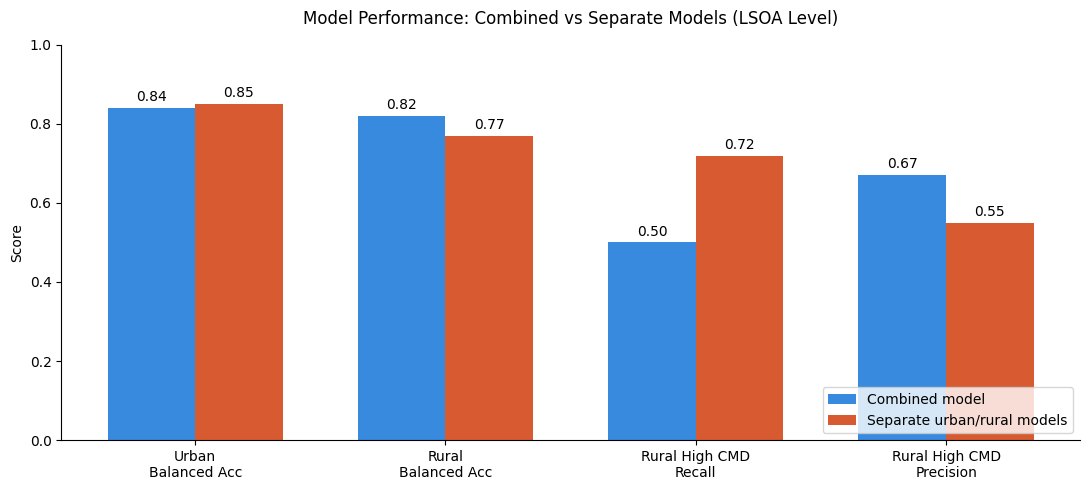

In [50]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Urban\nBalanced Acc', 'Rural\nBalanced Acc',
           'Rural High CMD\nRecall', 'Rural High CMD\nPrecision']

combined_model = [0.84, 0.82, 0.50, 0.67]
separate_models = [0.85, 0.77, 0.72, 0.55]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, combined_model, width,
               label='Combined model', color='#378ADD')
bars2 = ax.bar(x + width/2, separate_models, width,
               label='Separate urban/rural models', color='#D85A30')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score')
ax.set_title('Model Performance: Combined vs Separate Models (LSOA Level)',
             fontsize=12, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 7.0 SHAP Feature Importance Analysis

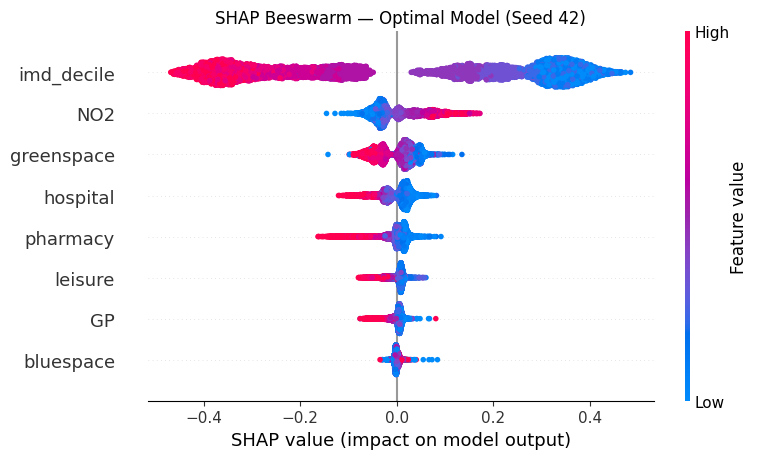

In [41]:
# SHAP beeswarm
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(best_test['X_test'])

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values[:, :, 1],
    best_test['X_test'],
    plot_type='dot',
    show=False,
    color_bar=True
)
plt.title(f'SHAP — Optimal Model)', fontsize=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Urban test MSOAs: 8441
Rural test MSOAs: 1686


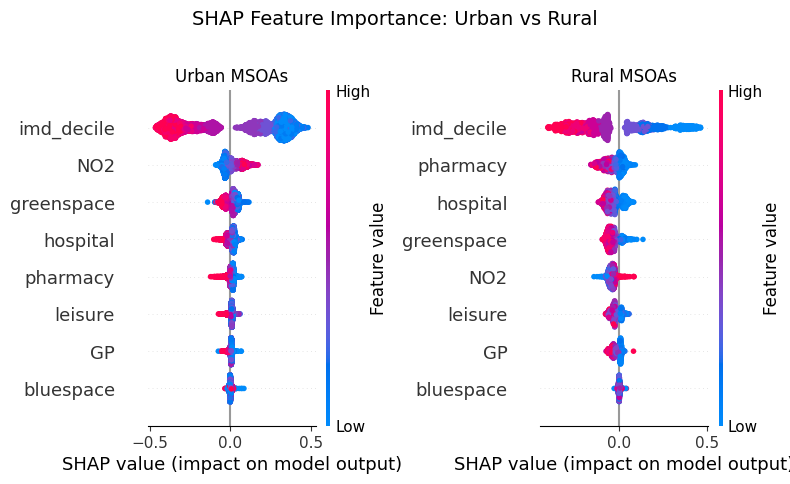

In [42]:
# First merge urban/rural flag back onto your test set
best_test_df = best_test['X_test'].copy()
best_test_df['Urban_rural_flag'] = df.loc[best_test_df.index, 'Urban_rural_flag']

# Split by urban/rural
urban_mask = best_test_df['Urban_rural_flag'] == 'Urban'
rural_mask = best_test_df['Urban_rural_flag'] == 'Rural'

X_urban = best_test['X_test'][urban_mask]
X_rural = best_test['X_test'][rural_mask]

print(f"Urban test MSOAs: {urban_mask.sum()}")
print(f"Rural test MSOAs: {rural_mask.sum()}")

# Compute SHAP values for each group
explainer = shap.TreeExplainer(best_rf)
shap_urban = explainer.shap_values(X_urban)
shap_rural = explainer.shap_values(X_rural)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.summary_plot(shap_urban[:,:,1], X_urban,
                  plot_type='dot', show=False)
axes[0].set_title('Urban MSOAs', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_rural[:,:,1], X_rural,
                  plot_type='dot', show=False)
axes[1].set_title('Rural MSOAs', fontsize=12)

plt.suptitle('SHAP Feature Importance: Urban vs Rural',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('shap_urban_rural.png', dpi=150, bbox_inches='tight')
plt.show()

# 8.0 Creating Two Seperate Datasets and Models for Rural and Urban MSOAs

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import GridSearchCV
import shap
import matplotlib.pyplot as plt
import seaborn as sns
param_grid = {
    'n_estimators': [200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}
def run_stratified_models(train_test_sets, random_states, df):

    urban_results = []
    rural_results  = []

    for i, s in enumerate(train_test_sets):

        # Get urban/rural masks for train and test
        train_indices = s['X_train'].index
        test_indices  = s['X_test'].index

        urban_train_mask = df.loc[train_indices, 'Urban_rural_flag'] == 'Urban'
        rural_train_mask = df.loc[train_indices, 'Urban_rural_flag'] == 'Rural'
        urban_test_mask  = df.loc[test_indices,  'Urban_rural_flag'] == 'Urban'
        rural_test_mask  = df.loc[test_indices,  'Urban_rural_flag'] == 'Rural'

        # Split train and test by urban/rural
        X_train_urban = s['X_train'][urban_train_mask]
        y_train_urban = s['y_train'][urban_train_mask]
        X_test_urban  = s['X_test'][urban_test_mask]
        y_test_urban  = s['y_test'][urban_test_mask]

        X_train_rural = s['X_train'][rural_train_mask]
        y_train_rural = s['y_train'][rural_train_mask]
        X_test_rural  = s['X_test'][rural_test_mask]
        y_test_rural  = s['y_test'][rural_test_mask]

        print(f"\nSeed {random_states[i]}:")
        print(f"  Urban  — train: {len(X_train_urban)}, test: {len(X_test_urban)}")
        print(f"  Rural  — train: {len(X_train_rural)}, test: {len(X_test_rural)}")
        print(f"  Rural train class dist: {y_train_rural.value_counts().to_dict()}")

        # --- Urban model ---
        gs_urban = GridSearchCV(
            RandomForestClassifier(random_state=42, class_weight='balanced'),
            param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1
        )
        gs_urban.fit(X_train_urban, y_train_urban)

        rf_urban = RandomForestClassifier(
            **gs_urban.best_params_,
            random_state=42,
            class_weight='balanced'
        )
        rf_urban.fit(X_train_urban, y_train_urban)
        y_pred_urban = rf_urban.predict(X_test_urban)
        urban_acc = balanced_accuracy_score(y_test_urban, y_pred_urban)

        # --- Rural model ---
        gs_rural = GridSearchCV(
            RandomForestClassifier(random_state=42, class_weight='balanced'),
            param_grid, cv=5, scoring='balanced_accuracy', n_jobs=-1
        )
        gs_rural.fit(X_train_rural, y_train_rural)

        rf_rural = RandomForestClassifier(
            **gs_rural.best_params_,
            random_state=42,
            class_weight='balanced'
        )
        rf_rural.fit(X_train_rural, y_train_rural)
        y_pred_rural = rf_rural.predict(X_test_rural)
        rural_acc = balanced_accuracy_score(y_test_rural, y_pred_rural)

        print(f"  Urban accuracy: {urban_acc:.4f}, params: {gs_urban.best_params_}")
        print(f"  Rural accuracy: {rural_acc:.4f}, params: {gs_rural.best_params_}")

        urban_results.append({
            'seed':     random_states[i],
            'accuracy': urban_acc,
            'model':    rf_urban,
            'X_test':   X_test_urban,
            'y_test':   y_test_urban,
            'y_pred':   y_pred_urban,
            'params':   gs_urban.best_params_
        })

        rural_results.append({
            'seed':     random_states[i],
            'accuracy': rural_acc,
            'model':    rf_rural,
            'X_test':   X_test_rural,
            'y_test':   y_test_rural,
            'y_pred':   y_pred_rural,
            'params':   gs_rural.best_params_
        })

    return urban_results, rural_results


# Run
urban_results, rural_results = run_stratified_models(
    train_test_sets, random_states, df
)

# Summary
urban_scores = [r['accuracy'] for r in urban_results]
rural_scores  = [r['accuracy'] for r in rural_results]
print(f"\nUrban — Mean: {np.mean(urban_scores):.4f}, Std: {np.std(urban_scores):.4f}")
print(f"Rural  — Mean: {np.mean(rural_scores):.4f},  Std: {np.std(rural_scores):.4f}")


Seed 40:
  Urban  — train: 19719, test: 8482
  Rural  — train: 3909, test: 1645
  Rural train class dist: {0: 2974, 1: 935}
  Urban accuracy: 0.8507, params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  Rural accuracy: 0.7700, params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Seed 41:
  Urban  — train: 19744, test: 8457
  Rural  — train: 3884, test: 1670
  Rural train class dist: {0: 2954, 1: 930}
  Urban accuracy: 0.8450, params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
  Rural accuracy: 0.7512, params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Seed 42:
  Urban  — train: 19760, test: 8441
  Rural  — train: 3868, test: 1686
  Rural train class dist: {0: 2943, 1: 925}
  Urban accuracy: 0.8412, params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
  Rural accuracy: 0.7603, params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}

Seed 43:
  Urban  — train: 19770, test: 8431
 

## 8.1 Reviewing the difference in Urban vs Rural Models

In [44]:
# Best urban and rural models
best_urban = max(urban_results, key=lambda x: x['accuracy'])
best_rural = max(rural_results,  key=lambda x: x['accuracy'])

print("=== URBAN — Best Model ===")
print(f"Seed: {best_urban['seed']}, Accuracy: {best_urban['accuracy']:.4f}")
print(classification_report(best_urban['y_test'], best_urban['y_pred'],
                            target_names=['Low CMD', 'High CMD']))

print("=== RURAL — Best Model ===")
print(f"Seed: {best_rural['seed']}, Accuracy: {best_rural['accuracy']:.4f}")
print(classification_report(best_rural['y_test'], best_rural['y_pred'],
                            target_names=['Low CMD', 'High CMD']))

=== URBAN — Best Model ===
Seed: 40, Accuracy: 0.8507
              precision    recall  f1-score   support

     Low CMD       0.83      0.84      0.84      3810
    High CMD       0.87      0.86      0.87      4672

    accuracy                           0.85      8482
   macro avg       0.85      0.85      0.85      8482
weighted avg       0.85      0.85      0.85      8482

=== RURAL — Best Model ===
Seed: 44, Accuracy: 0.7722
              precision    recall  f1-score   support

     Low CMD       0.91      0.82      0.86      1270
    High CMD       0.55      0.72      0.62       377

    accuracy                           0.80      1647
   macro avg       0.73      0.77      0.74      1647
weighted avg       0.83      0.80      0.81      1647



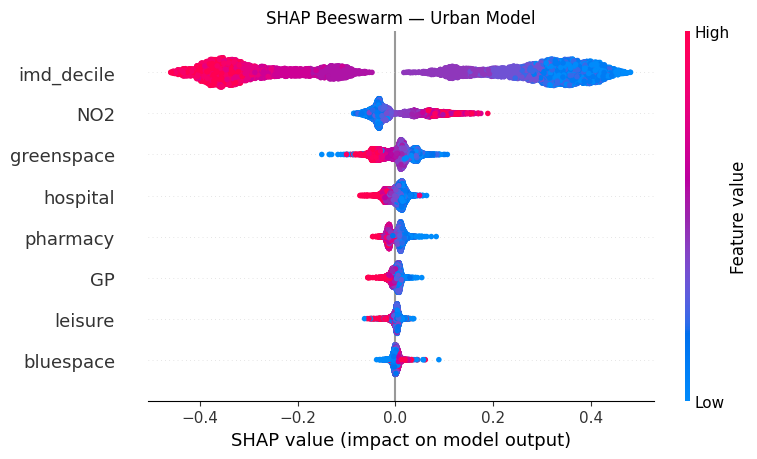

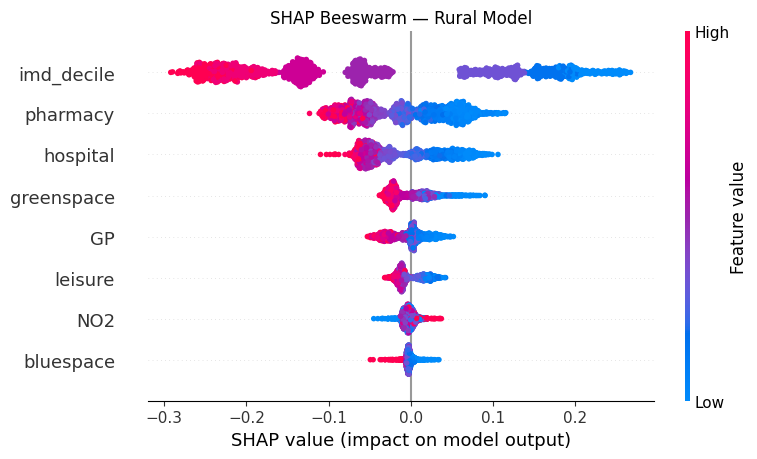

In [45]:
# Get best urban and rural models
explainer_urban = shap.TreeExplainer(best_urban['model'])
explainer_rural = shap.TreeExplainer(best_rural['model'])

shap_urban = explainer_urban.shap_values(best_urban['X_test'])
shap_rural = explainer_rural.shap_values(best_rural['X_test'])

# --- Urban SHAP ---
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_urban[:,:,1],
    best_urban['X_test'],
    plot_type='dot',
    show=False
)
plt.title('SHAP Beeswarm — Urban Model', fontsize=12)
plt.tight_layout()
plt.savefig('shap_urban.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Rural SHAP ---
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_rural[:,:,1],
    best_rural['X_test'],
    plot_type='dot',
    show=False
)
plt.title('SHAP Beeswarm — Rural Model', fontsize=12)
plt.tight_layout()
plt.savefig('shap_rural.png', dpi=150, bbox_inches='tight')
plt.show()

# 9.0 Visualising Results in Geopands

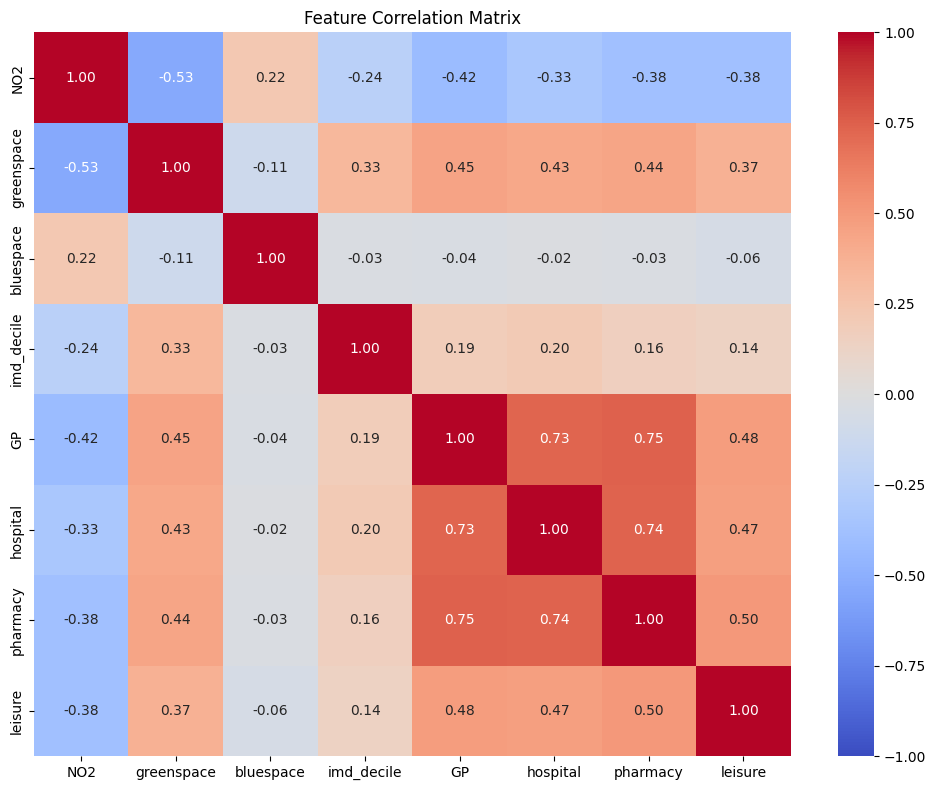

In [46]:
import seaborn as sns
import geopandas as gpd
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
import pandas as pd

# Check current proportions in the full dataset
print("=== FULL DATASET ===")
print("Total LSOAs:", len(df))
print("\nOverall high_cmd distribution:")
print(df['high_cmd'].value_counts(normalize=True).round(3))

print("\nBy urban/rural:")
cross_tab = pd.crosstab(
    df['Urban_rural_flag'],
    df['high_cmd'],
    normalize='index'
).round(3) * 100

print(cross_tab)

# Raw counts
print("\nRaw counts by urban/rural and cmd:")
print(pd.crosstab(df['Urban_rural_flag'], df['high_cmd']))

# Check stratification in test sets
print("\n=== TEST SET STRATIFICATION CHECK ===")
for i, s in enumerate(train_test_sets):
    test_indices = s['X_test'].index
    test_df = df.loc[test_indices]

    print(f"\nSeed {random_states[i]}:")
    print(pd.crosstab(
        test_df['Urban_rural_flag'],
        test_df['high_cmd'],
        normalize='index'
    ).round(3) * 100)

=== FULL DATASET ===
Total LSOAs: 33755

Overall high_cmd distribution:
high_cmd
0    0.5
1    0.5
Name: proportion, dtype: float64

By urban/rural:
high_cmd             0     1
Urban_rural_flag            
Rural             76.1  23.9
Urban             44.9  55.1

Raw counts by urban/rural and cmd:
high_cmd              0      1
Urban_rural_flag              
Rural              4228   1326
Urban             12650  15551

=== TEST SET STRATIFICATION CHECK ===

Seed 40:
high_cmd             0     1
Urban_rural_flag            
Rural             76.2  23.8
Urban             44.9  55.1

Seed 41:
high_cmd             0     1
Urban_rural_flag            
Rural             76.3  23.7
Urban             44.8  55.2

Seed 42:
high_cmd             0     1
Urban_rural_flag            
Rural             76.2  23.8
Urban             44.8  55.2

Seed 43:
high_cmd             0     1
Urban_rural_flag            
Rural             76.6  23.4
Urban             44.7  55.3

Seed 44:
high_cmd             0

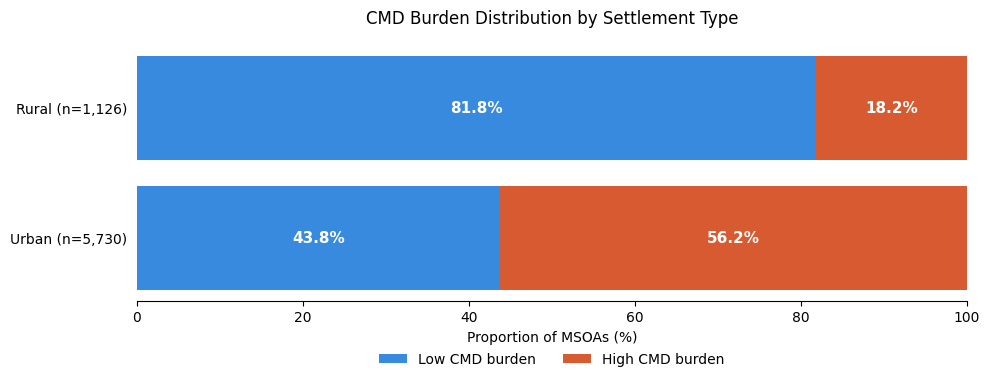

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['Urban (n=5,730)', 'Rural (n=1,126)']
low_cmd = [43.8, 81.8]
high_cmd = [56.2, 18.2]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

# Horizontal stacked bars
bars1 = ax.barh(categories, low_cmd, color='#378ADD', label='Low CMD burden')
bars2 = ax.barh(categories, high_cmd, left=low_cmd, color='#D85A30', label='High CMD burden')

# Add percentage labels inside bars
for i, (low, high) in enumerate(zip(low_cmd, high_cmd)):
    ax.text(low/2, i, f'{low}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)
    ax.text(low + high/2, i, f'{high}%', ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)

# Styling
ax.set_xlim(0, 100)
ax.set_xlabel('Proportion of MSOAs (%)')
ax.set_title('CMD Burden Distribution by Settlement Type',
             fontsize=12, pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False)

# Remove spines and ticks for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig('cmd_proportions.png', dpi=150, bbox_inches='tight')
plt.show()

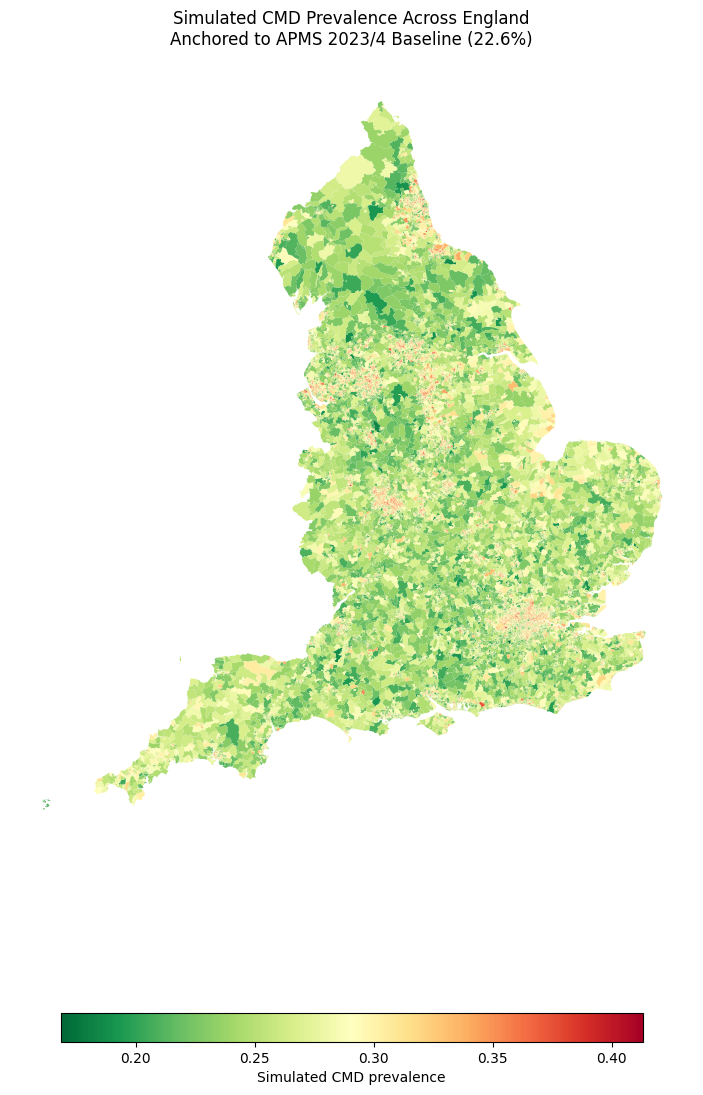

In [38]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load your LSOA shapefile (update path if different)
gdf = gpd.read_file('/content/LSOA_2021_EW_BSC_V4.shp')

# Merge with your dataframe
gdf = gdf.merge(df[['LSOA21CD', 'cmd_prevalence', 'high_cmd',
                    'Urban_rural_flag', 'NO2']],
                left_on='LSOA21CD', right_on='LSOA21CD')

# Single choropleth of simulated CMD prevalence
fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(column='cmd_prevalence',
         cmap='RdYlGn_r',
         legend=True,
         linewidth=0,
         ax=ax,
         legend_kwds={'label': 'Simulated CMD prevalence',
                      'orientation': 'horizontal',
                      'shrink': 0.6})

ax.set_title('Simulated CMD Prevalence Across England\n'
             'Anchored to APMS 2023/4 Baseline (22.6%)',
             fontsize=12, pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('cmd_map.png', dpi=150, bbox_inches='tight')
plt.show()

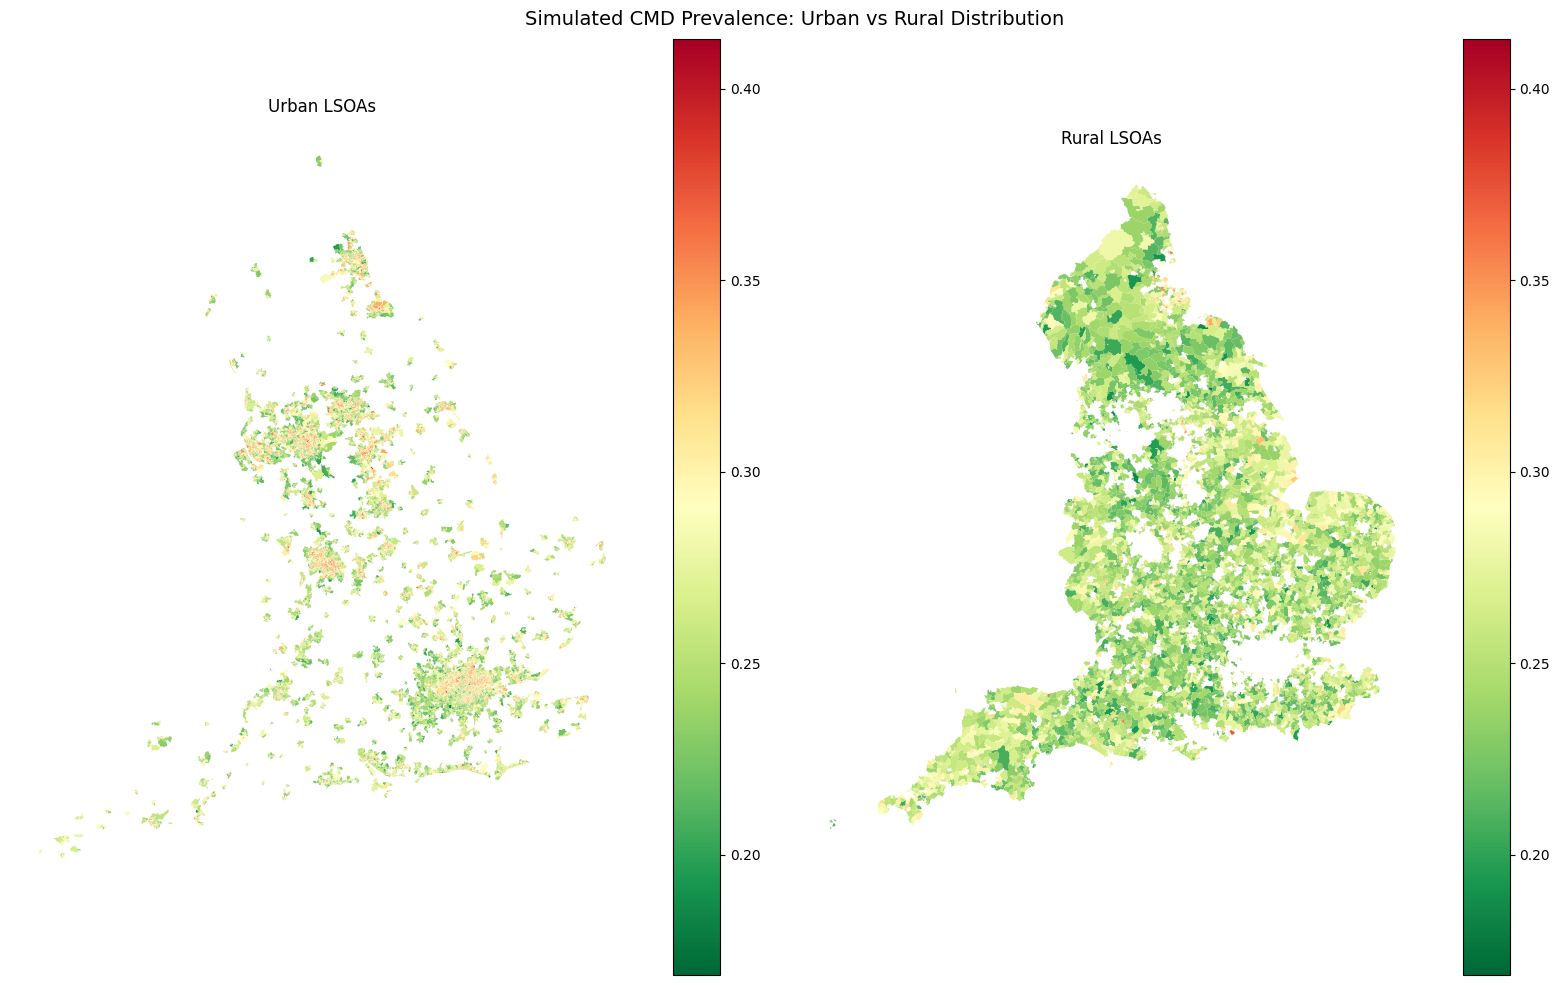

In [39]:
# Two-panel map comparing urban and rural distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Urban only
urban_gdf = gdf[gdf['Urban_rural_flag'] == 'Urban']
urban_gdf.plot(column='cmd_prevalence', cmap='RdYlGn_r',
               legend=True, linewidth=0, ax=axes[0],
               vmin=gdf['cmd_prevalence'].min(),
               vmax=gdf['cmd_prevalence'].max())
axes[0].set_title('Urban LSOAs', fontsize=12)
axes[0].axis('off')

# Rural only
rural_gdf = gdf[gdf['Urban_rural_flag'] == 'Rural']
rural_gdf.plot(column='cmd_prevalence', cmap='RdYlGn_r',
               legend=True, linewidth=0, ax=axes[1],
               vmin=gdf['cmd_prevalence'].min(),
               vmax=gdf['cmd_prevalence'].max())
axes[1].set_title('Rural LSOAs', fontsize=12)
axes[1].axis('off')

plt.suptitle('Simulated CMD Prevalence: Urban vs Rural Distribution',
             fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('cmd_map_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
print([col for col in gdf.columns if 'NO' in col or 'no' in col.lower()])

['NO2']


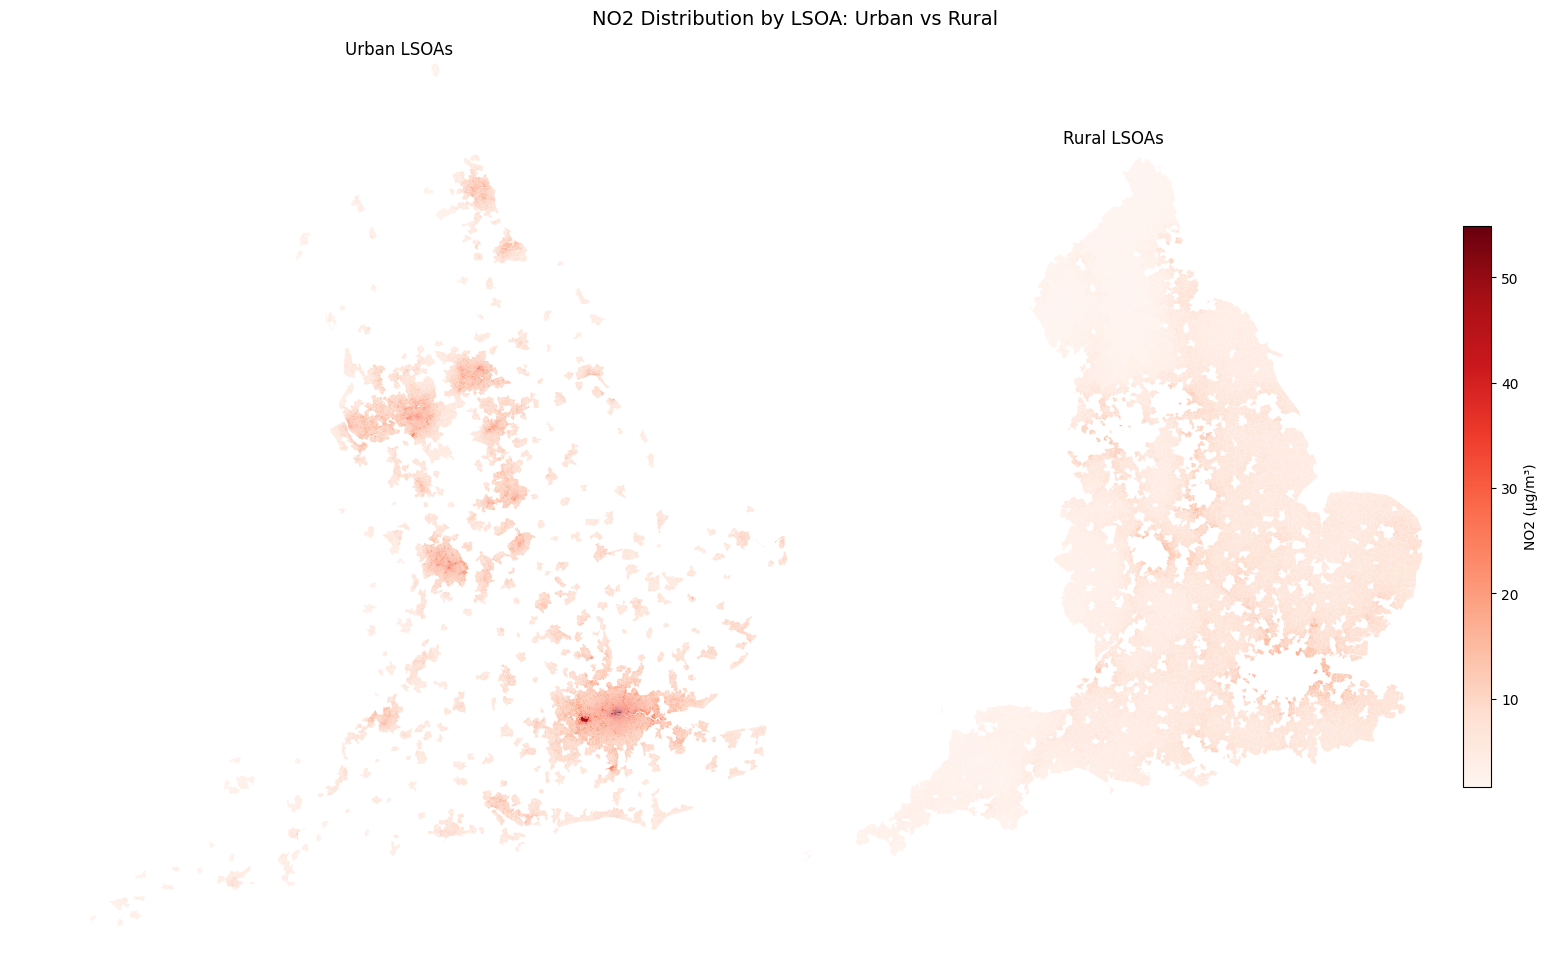

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Get shared bounds from full dataset
bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]

urban_gdf = gdf[gdf['Urban_rural_flag'] == 'Urban']
urban_gdf.plot(column='NO2', cmap='Reds',
               legend=False, linewidth=0.05, edgecolor='white',
               ax=axes[0],
               vmin=gdf['NO2'].min(), vmax=gdf['NO2'].max())
axes[0].set_title('Urban LSOAs', fontsize=12)
axes[0].set_xlim(bounds[0], bounds[2])
axes[0].set_ylim(bounds[1], bounds[3])
axes[0].axis('off')

rural_gdf = gdf[gdf['Urban_rural_flag'] == 'Rural']
rural_gdf.plot(column='NO2', cmap='Reds',
               legend=True, linewidth=0.05, edgecolor='white',
               ax=axes[1],
               vmin=gdf['NO2'].min(), vmax=gdf['NO2'].max(),
               legend_kwds={'label': 'NO2 (μg/m³)',
                            'orientation': 'vertical',
                            'shrink': 0.6})
axes[1].set_title('Rural LSOAs', fontsize=12)
axes[1].set_xlim(bounds[0], bounds[2])
axes[1].set_ylim(bounds[1], bounds[3])
axes[1].axis('off')

plt.suptitle('NO2 Distribution by LSOA: Urban vs Rural',
             fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('no2_map_split.png', dpi=200, bbox_inches='tight')
plt.show()

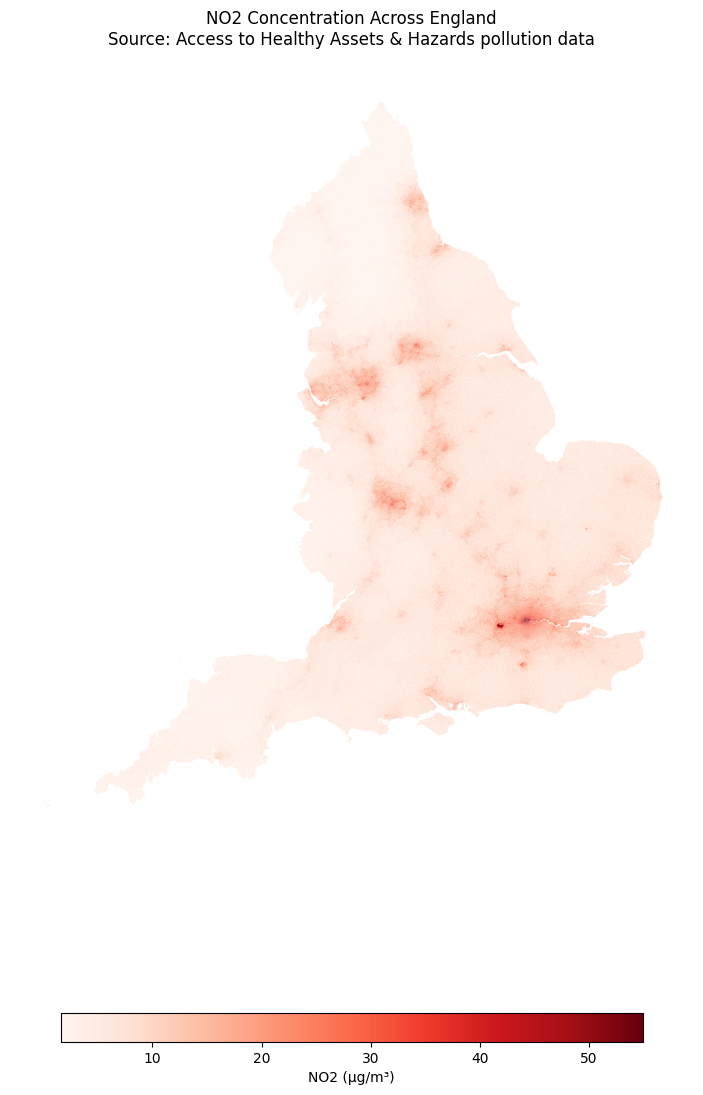

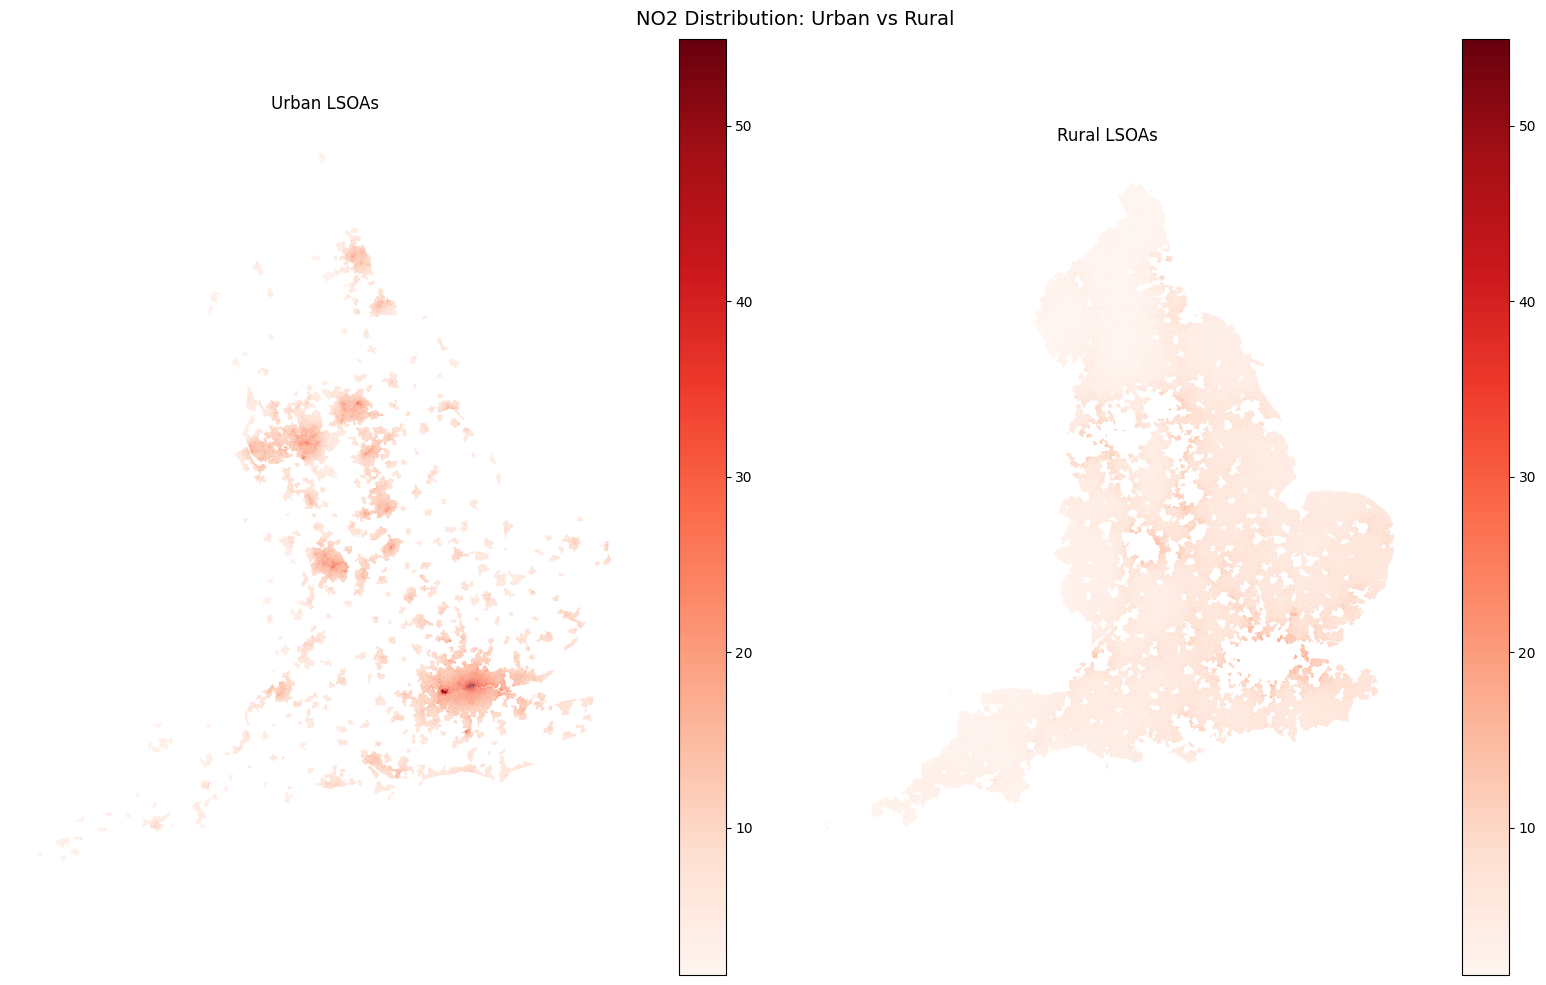

In [42]:
# Single choropleth of NO2
fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(column='NO2',
         cmap='Reds',
         legend=True,
         linewidth=0,
         ax=ax,
         legend_kwds={'label': 'NO2 (μg/m³)',
                      'orientation': 'horizontal',
                      'shrink': 0.6})

ax.set_title('NO2 Concentration Across England\n'
             'Source: Access to Healthy Assets & Hazards pollution data',
             fontsize=12, pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('no2_map.png', dpi=150, bbox_inches='tight')
plt.show()


# Two-panel map comparing urban and rural NO2
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

urban_gdf = gdf[gdf['Urban_rural_flag'] == 'Urban']
urban_gdf.plot(column='NO2', cmap='Reds',
               legend=True, linewidth=0, ax=axes[0],
               vmin=gdf['NO2'].min(),
               vmax=gdf['NO2'].max())
axes[0].set_title('Urban LSOAs', fontsize=12)
axes[0].axis('off')

rural_gdf = gdf[gdf['Urban_rural_flag'] == 'Rural']
rural_gdf.plot(column='NO2', cmap='Reds',
               legend=True, linewidth=0, ax=axes[1],
               vmin=gdf['NO2'].min(),
               vmax=gdf['NO2'].max())
axes[1].set_title('Rural LSOAs', fontsize=12)
axes[1].axis('off')

plt.suptitle('NO2 Distribution: Urban vs Rural',
             fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('no2_map_split.png', dpi=150, bbox_inches='tight')
plt.show()